# Step 6 -- 2D Nonlinear Convection

We now replace the constant advection velocity with the solution itself, giving the 2D nonlinear convection (inviscid Burgers) system:

$$
\frac{\partial u}{\partial t}
+ u \frac{\partial u}{\partial x}
+ v \frac{\partial u}{\partial y} = 0
$$

$$
\frac{\partial v}{\partial t}
+ u \frac{\partial v}{\partial x}
+ v \frac{\partial v}{\partial y} = 0
$$

**What you will learn:**

1. How nonlinear self-advection produces wave steepening in 2D
2. Working with two-component state vectors $(u, v)$
3. How the solution differs from the linear case

## Physics

In the linear case (Step 5) the wave translates at constant speed without changing shape. Here the local propagation speed *is* the solution: regions of higher amplitude travel faster, causing the wave front to steepen. Without viscosity, this eventually leads to a shock (gradient blow-up). In practice we run for a short time to observe the steepening before any numerical instability.

## Grid layout and boundary conditions

In 2D, somax uses the **Arakawa C-grid** where different variables live at different positions within each cell:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

- **T-points** (cell centres): scalars ($u$, $p$, $\omega$)
- **U-points** (east/west faces): x-fluxes
- **V-points** (north/south faces): y-fluxes
- **X-points** (corners): vorticity (in some formulations)

The full array has shape `(Ny, Nx)` with a **1-cell ghost ring** on all sides:

```
 ┌───────────────────────────────────┐
 │  ghost  ghost  ghost  ghost  ghost│  ← row 0
 │  ghost  T(1,1) T(1,2) ···   ghost│  ← row 1
 │  ghost  T(2,1) T(2,2) ···   ghost│
 │   ⋮      ⋮      ⋮           ⋮    │
 │  ghost  T(n,1) T(n,2) ···   ghost│  ← row Ny-2
 │  ghost  ghost  ghost  ghost  ghost│  ← row Ny-1
 └───────────────────────────────────┘
        col 0  col 1  ···  col Nx-1
```

Interior cells are `[1:-1, 1:-1]`. Ghost cells are filled by boundary conditions before each RHS evaluation.

**Periodic BCs** (`enforce_periodic`) copy the last interior row/column to the opposite ghost row/column. Both `u` and `v` fields receive the same periodic treatment:

```
 field[0, :]  = field[-2, :]   (south ghost ← north interior)
 field[-1, :] = field[1, :]    (north ghost ← south interior)
 field[:, 0]  = field[:, -2]   (west ghost ← east interior)
 field[:, -1] = field[:, 1]    (east ghost ← west interior)
```

In [1]:
from __future__ import annotations

import diffrax as dfx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import NonlinearConvection2D, NonlinearConvection2DState

## 1. Create the model

In [2]:
model = NonlinearConvection2D.create(nx=64, ny=64)
print(model)
print(f"Grid: Nx={model.grid.Nx}, Ny={model.grid.Ny}")
print(f"Spacing: dx={model.grid.dx:.4f}, dy={model.grid.dy:.4f}")

NonlinearConvection2D(
  grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125),
  advection=Advection2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125),
    recon=Reconstruction2D(
      grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
    )
  ),
  interp=Interpolation2D(
    grid=ArakawaCGrid2D(Nx=66, Ny=66, Lx=2.0, Ly=2.0, dx=0.03125, dy=0.03125)
  )
)
Grid: Nx=66, Ny=66
Spacing: dx=0.0312, dy=0.0312


## 2. Initial condition

A 2D Gaussian for both velocity components, centred at $(1.0, 1.0)$.

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
y = jnp.arange(model.grid.Ny) * model.grid.dy
X, Y = jnp.meshgrid(x, y)

sigma0 = 0.2
gauss = jnp.exp(-0.5 * (((X - 1.0) / sigma0) ** 2 + ((Y - 1.0) / sigma0) ** 2))
u0 = gauss
v0 = gauss

state0 = NonlinearConvection2DState(u=u0, v=v0)
print(f"State shapes: u={state0.u.shape}, v={state0.v.shape}")

State shapes: u=(66, 66), v=(66, 66)


## 3. Run the simulation

In [4]:
dt = 0.002
t_final = 0.3
ts = jnp.arange(0.0, t_final, dt)

sol = model.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Solution shapes: u={sol.ys.u.shape}, v={sol.ys.v.shape}")

Solution shapes: u=(150, 66, 66), v=(150, 66, 66)


## 4. Visualize steepening

Compare the initial and final $u$ and $v$ fields. The Gaussian should steepen on one side as faster-moving peaks overtake slower regions.

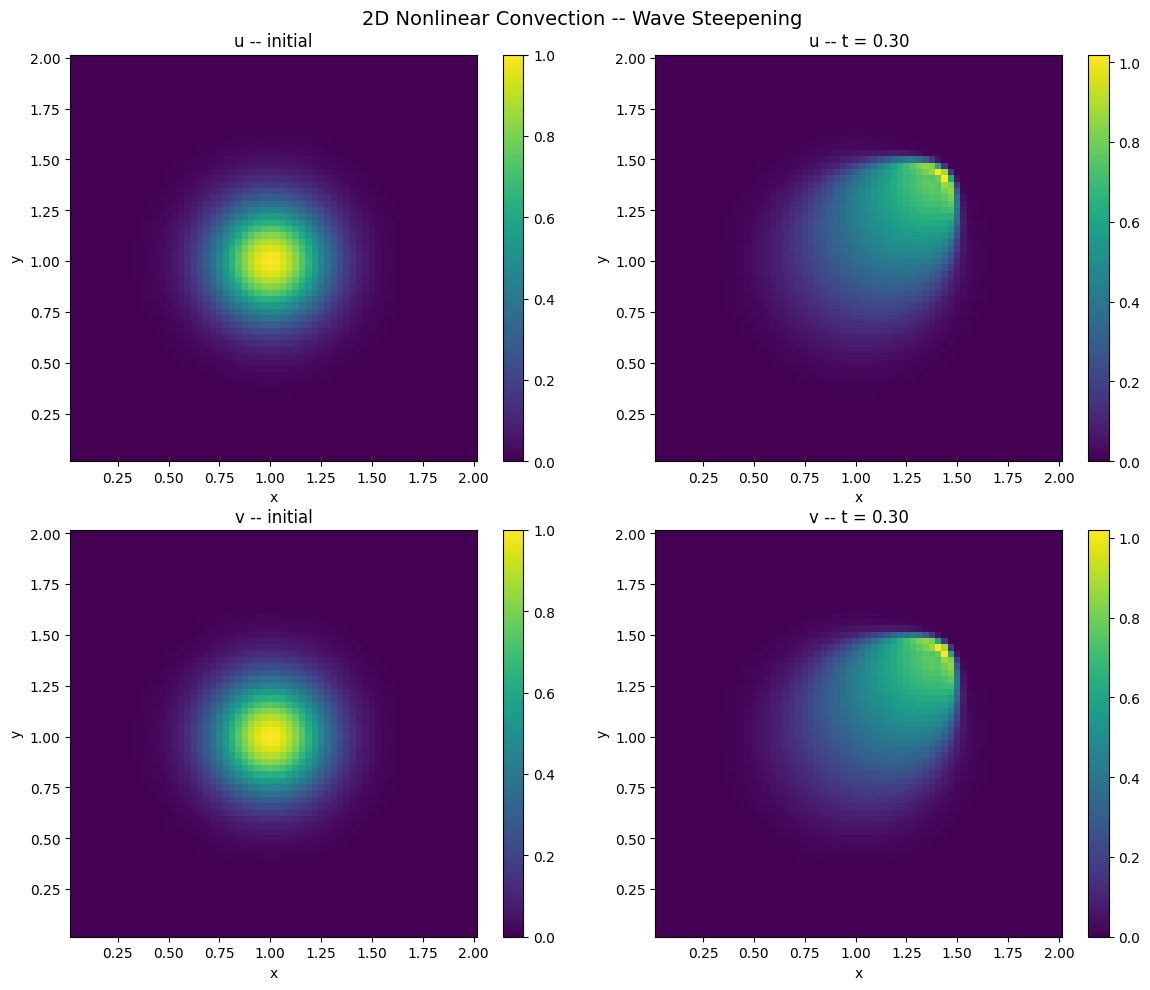

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fields = [
    (sol.ys.u[0], "u -- initial"),
    (sol.ys.u[-1], f"u -- t = {float(ts[-1]):.2f}"),
    (sol.ys.v[0], "v -- initial"),
    (sol.ys.v[-1], f"v -- t = {float(ts[-1]):.2f}"),
]

for ax, (field, title) in zip(axes.ravel(), fields, strict=True):
    pcm = ax.pcolormesh(
        X[1:-1, 1:-1],
        Y[1:-1, 1:-1],
        field[1:-1, 1:-1],
        shading="auto",
        cmap="viridis",
    )
    plt.colorbar(pcm, ax=ax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal")

plt.suptitle("2D Nonlinear Convection -- Wave Steepening", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Cross-sections through the steepening front

Taking a 1D slice through the middle row makes the steepening easier to see.

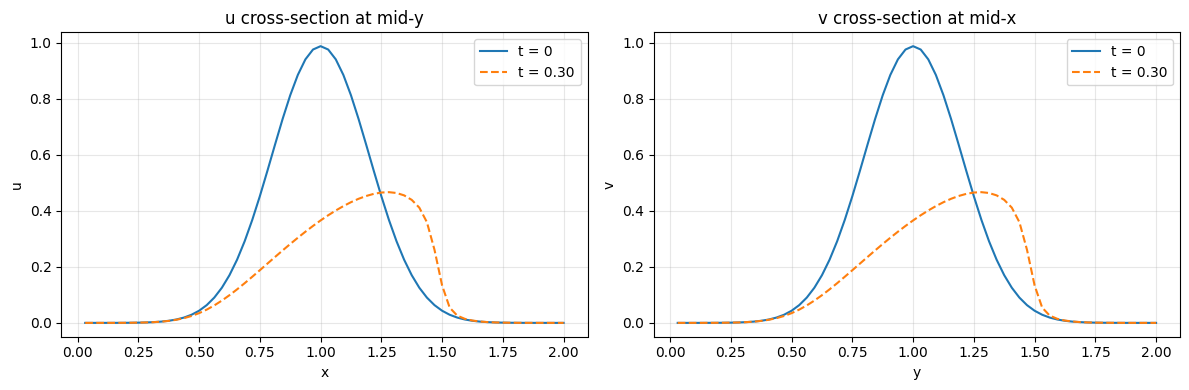

In [6]:
mid_y = model.grid.Ny // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# u cross-section
axes[0].plot(x[1:-1], sol.ys.u[0, mid_y, 1:-1], label="t = 0", lw=1.5)
axes[0].plot(
    x[1:-1],
    sol.ys.u[-1, mid_y, 1:-1],
    label=f"t = {float(ts[-1]):.2f}",
    lw=1.5,
    ls="--",
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].set_title("u cross-section at mid-y")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# v cross-section
mid_x = model.grid.Nx // 2
axes[1].plot(y[1:-1], sol.ys.v[0, 1:-1, mid_x], label="t = 0", lw=1.5)
axes[1].plot(
    y[1:-1],
    sol.ys.v[-1, 1:-1, mid_x],
    label=f"t = {float(ts[-1]):.2f}",
    lw=1.5,
    ls="--",
)
axes[1].set_xlabel("y")
axes[1].set_ylabel("v")
axes[1].set_title("v cross-section at mid-x")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Compare with linear convection

In the linear case (Step 5) the peak amplitude is preserved. Here self-advection redistributes energy and the peak drops as the front steepens.

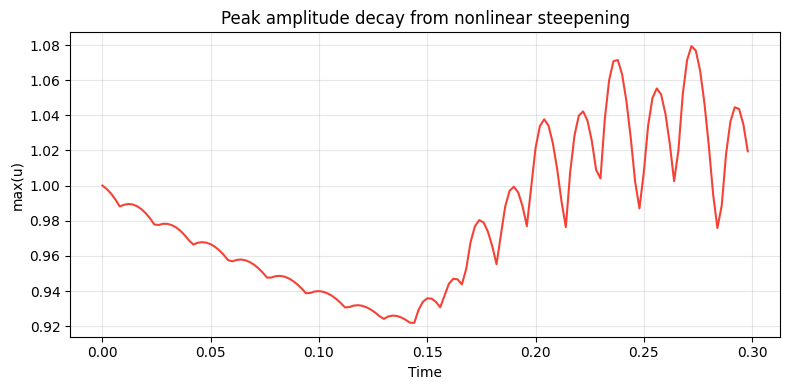

In [7]:
peak_u = jnp.max(sol.ys.u[:, 1:-1, 1:-1], axis=(1, 2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, peak_u, lw=1.5, color="#F44336")
ax.set_xlabel("Time")
ax.set_ylabel("max(u)")
ax.set_title("Peak amplitude decay from nonlinear steepening")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Energy evolution

Total kinetic energy $E = \tfrac{1}{2}\sum(u^2 + v^2)\,dx\,dy$ should *not* increase for this inviscid system (numerical dissipation may cause a slight decrease).

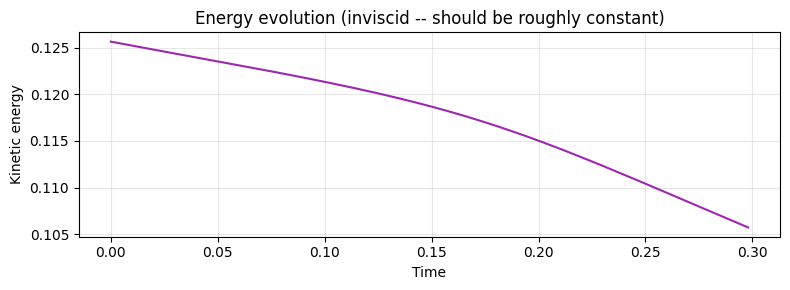

Energy: initial = 0.125664, final = 0.105718


In [8]:
dx_val, dy_val = float(model.grid.dx), float(model.grid.dy)
energy = (
    0.5
    * jnp.sum(
        sol.ys.u[:, 1:-1, 1:-1] ** 2 + sol.ys.v[:, 1:-1, 1:-1] ** 2,
        axis=(1, 2),
    )
    * dx_val
    * dy_val
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ts, energy, lw=1.5, color="#9C27B0")
ax.set_xlabel("Time")
ax.set_ylabel("Kinetic energy")
ax.set_title("Energy evolution (inviscid -- should be roughly constant)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Energy: initial = {float(energy[0]):.6f}, final = {float(energy[-1]):.6f}")

## 8. Gradient through the initial state

Even without explicit parameters, we can differentiate through the nonlinear dynamics with respect to the initial condition.

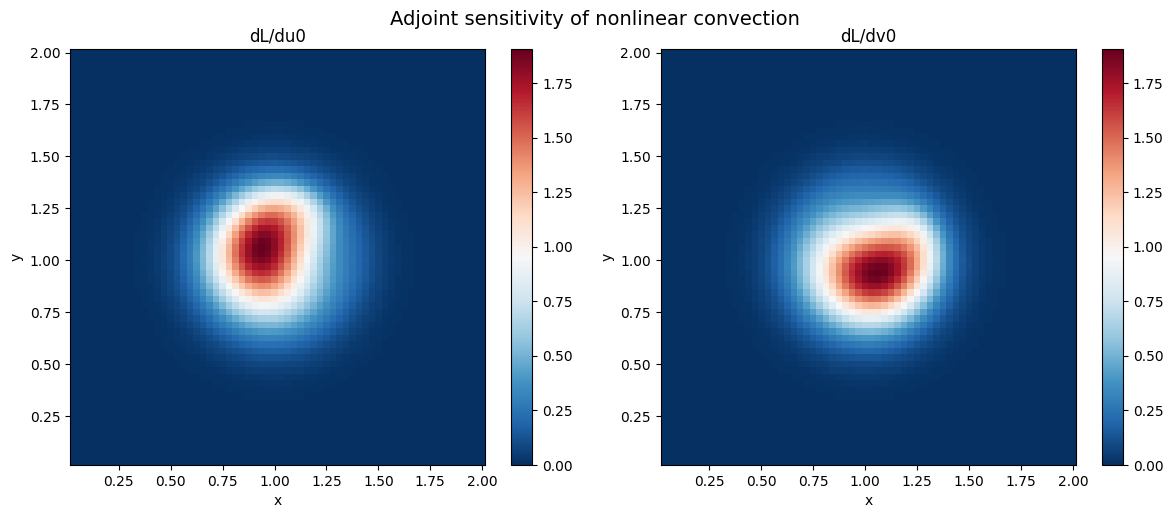

In [9]:
def loss_state(s0):
    sol = model.integrate(s0, t0=0.0, t1=0.1, dt=0.002)
    return jnp.sum(sol.ys.u**2 + sol.ys.v**2)


grad_s0 = jax.grad(loss_state)(state0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pcm0 = axes[0].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    grad_s0.u[1:-1, 1:-1],
    shading="auto",
    cmap="RdBu_r",
)
plt.colorbar(pcm0, ax=axes[0])
axes[0].set_title("dL/du0")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

pcm1 = axes[1].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    grad_s0.v[1:-1, 1:-1],
    shading="auto",
    cmap="RdBu_r",
)
plt.colorbar(pcm1, ax=axes[1])
axes[1].set_title("dL/dv0")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.suptitle("Adjoint sensitivity of nonlinear convection", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

| Concept | API |
|---------|-----|
| Create model | `NonlinearConvection2D.create(nx=64, ny=64)` |
| Two-component state | `NonlinearConvection2DState(u=u0, v=v0)` |
| Self-advection | velocity = solution itself |
| Observable effect | wave steepening, peak decay |

**Next:** Step 7 adds diffusion in 2D, which counteracts steepening and has an analytical Gaussian solution we can validate against.